Download [dataset](https://www.kaggle.com/competitions/classification-of-oil-and-gas)

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

torch.random.manual_seed(42)
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else "cpu"
learning_rate = 1e-3
batch_size = 64
epochs = 1000

device

device(type='mps')

In [106]:
train = pd.read_csv("data/train_oil.csv")
test = pd.read_csv("data/oil_test.csv")

train

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,HIDES,IMBURU-TORO,PAPUA NEW GUINEA,FAR EAST,PAPUAN FTB,COMPRESSION,-6.0136,142.8409,OIL SEARCH LTD,ONSHORE,GAS-CONDENSATE,CONTINUING DEVELOPMENT,THRUST,9905,JURASSIC-CRETACEOUS,SANDSTONE,490.0,240.0,10.0,100.0
305,DRAKE POINT,DRAKE POINT-INTREPID INLET,CANADA,NORTH AMERICA,SVERDRUP,COMPRESSION/EVAPORITE/EXTENSION/LINKED,76.4462,-108.9172,PANARCTIC OILS,ONSHORE,GAS,UNDEVELOPED,FORELAND,3390,JURASSIC,SANDSTONE,100.0,71.0,20.0,566.0
306,ALTAMONT-BLUEBELL,GREEN RIVER AND COLTON/WASATCH,USA,NORTH AMERICA,UINTA,COMPRESSION,40.3000,-110.2100,NUMEROUS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,15250,PALEOGENE,SANDSTONE,8000.0,575.0,5.0,0.1
307,BELL CREEK,MUDDY,USA,NORTH AMERICA,POWDER RIVER,COMPRESSION,45.1039,-105.0967,SAMUEL GARY,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4300,CRETACEOUS,SANDSTONE,45.0,23.0,28.5,2250.0


In [107]:
from preprocessor import OilFieldClassificationPreprocessor

preprocessor = OilFieldClassificationPreprocessor()

/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['ALGERIA', 'COLOMBIA', 'IRAQ', 'LIBYA', 'UZBEKISTAN'] will be ignored
  warnings.warn(
/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['ALBERTA ENERGY COMPANY', 'BANF AND AQUITAINE', 'BRITTANIA OPERATOR LIMITED', 'BTA OIL PRODUCERS', 'CALTEX PACIFIC', 'EXXONMOBIL AND OTHERS', 'HUNT OIL COMPANY', 'INOC', 'KARACHAGANAK INTEGRATED ORAGANIZATION', 'LNOC', 'NEXEN', 'NIELSON and ASSOCIATES INC', 'NIZHNEVOLZHSKNET', 'NOYABRSKNEFTEGAS', 'PAN AMERICAN PETROLEUM', 'PERENCO', 'PLUSPETROL', 'RUSIA PETROLEUM', 'SIBNEFT (MURAVLENKOVSKNEFT)', 'SITEP', 'SONATRACH', 'SREDAZGAZPROM', 'TENGIZCHEVROIL', 'VOSTSIBNEFTEGAZGEOLOGIYA', 'WESTCOAST PETROLEUM'] will be ignored
  warnings.warn(
/Users/andrey/Ground/25AIMEPhI/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:100

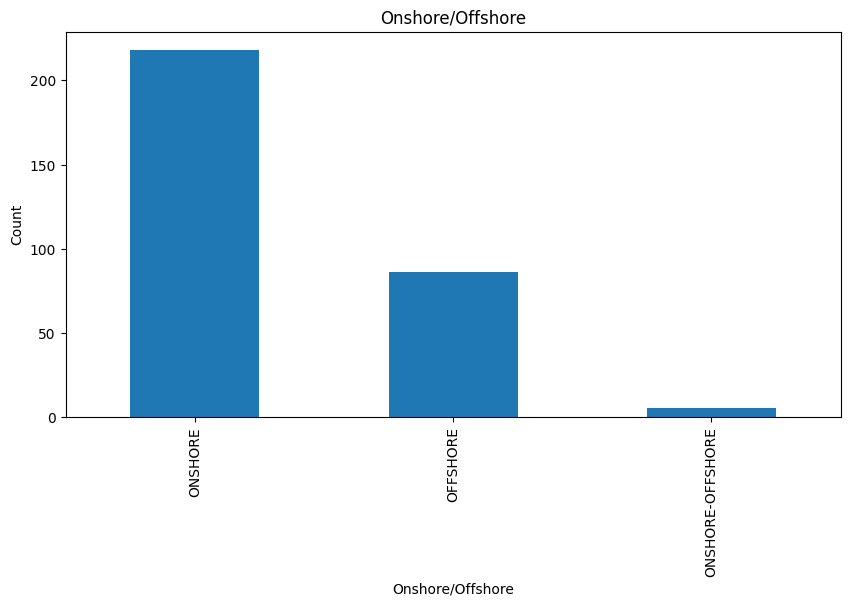

In [108]:
from torch.utils.data import DataLoader, TensorDataset

splits = preprocessor.prepare_training_data(train, use_validation=True, val_size=0.2)
train_ready = splits["train"]
val_ready = splits["val"]
test_ready = preprocessor.transform(test)

# pandas -> torch tensors
x_train = torch.tensor(train_ready.drop(columns=["Onshore/Offshore"]).to_numpy(), dtype=torch.float32)
y_train = torch.tensor(train_ready["Onshore/Offshore"].to_numpy(), dtype=torch.long)

x_val = torch.tensor(val_ready.drop(columns=["Onshore/Offshore"]).to_numpy(), dtype=torch.float32)
y_val = torch.tensor(val_ready["Onshore/Offshore"].to_numpy(), dtype=torch.long)

x_test = torch.tensor(test_ready.to_numpy(), dtype=torch.float32)

train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

plt.figure(figsize=(10, 5))
train["Onshore/Offshore"].value_counts().plot(kind="bar")
plt.title("Onshore/Offshore")
plt.xlabel("Onshore/Offshore")
plt.ylabel("Count")
plt.show()


In [109]:
import torch.nn as nn
import torch.optim as optim
n_features = len(preprocessor.feature_columns_)
n_classes = len(preprocessor.TARGET_MAPPING)

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Sequential(
            nn.Linear(n_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.linear(x)
        return x

net = Net().to(device)
optimizer = optim.Adam(net.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [110]:
from trainer import Trainer

trainer = Trainer(net, criterion, optimizer, device)
trainer.fit(train_loader, val_loader)


Эпоха: 0 Loss_train: 0.6831415858533647, 0:00:00.033341 сек
Loss_val: 0.8153526782989502

Эпоха: 1 Loss_train: 0.24143868684768677, 0:00:00.025133 сек
Loss_val: 0.534003734588623

Эпоха: 2 Loss_train: 0.11414294358756807, 0:00:00.023410 сек
Loss_val: 0.4047749936580658

Эпоха: 3 Loss_train: 0.08459602710273531, 0:00:00.021834 сек
Loss_val: 0.4111001193523407

Эпоха: 4 Loss_train: 0.0473429879380597, 0:00:00.021369 сек
Loss_val: 0.39545637369155884

Эпоха: 5 Loss_train: 0.03842653975718551, 0:00:00.021434 сек
Loss_val: 0.403697669506073

Эпоха: 6 Loss_train: 0.036236139428284436, 0:00:00.021030 сек
Loss_val: 0.42140719294548035

Эпоха: 7 Loss_train: 0.02325095867531167, 0:00:00.020776 сек
Loss_val: 0.4575728178024292

Эпоха: 8 Loss_train: 0.019347071854604617, 0:00:00.021258 сек
Loss_val: 0.46774229407310486

Эпоха: 9 Loss_train: 0.027079880548020203, 0:00:00.020769 сек
Loss_val: 0.462237685918808

Эпоха: 10 Loss_train: 0.016923684626817703, 0:00:00.020745 сек
Loss_val: 0.46309927105903

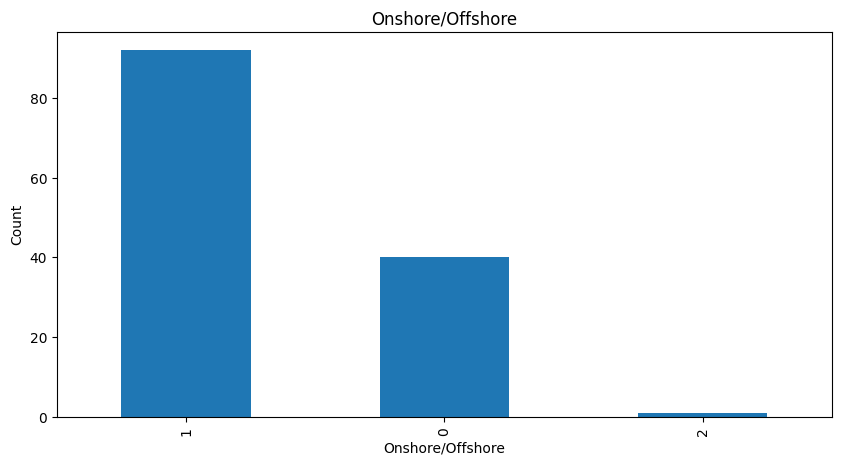

In [111]:
predictions = trainer.predict(test_loader)
predictions = pd.DataFrame(predictions.softmax(dim=1).argmax(dim=1).numpy())
predictions.columns = ["Onshore/Offshore"]
predictions = predictions.reset_index()
predictions.to_csv("data/predictions.csv", index=False)

plt.figure(figsize=(10, 5))
predictions["Onshore/Offshore"].value_counts().plot(kind="bar")
plt.title("Onshore/Offshore")
plt.xlabel("Onshore/Offshore")
plt.ylabel("Count")
plt.show()
